# Lightweight Remote-Sensing Image Super-Resolution with ReFDN

This notebook implements the Re-Parameterized Feature Distillation Network (ReFDN) for lightweight remote-sensing image super-resolution (RSISR) using the UC Merced LandUse dataset. It includes data preprocessing, the full ReFDN model with re-parameterization (MultiConv, ECSA, ReFDB), training, testing, and evaluation, following the methodology of the ReFDN paper.

## Step 1: Import Libraries and Set Up Environment

In [8]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
import shutil
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import tqdm

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
if not torch.cuda.is_available():
    print('Warning: CUDA not available, running on CPU. Training may be slow.')
else:
    print('CUDA Device:', torch.cuda.get_device_name(0))
print('PyTorch Version:', torch.__version__)

# Define paths
UCM_FOLDER = r"C:\SR_Project(2ndsem)\UCMerced_LandUse\Images"
OUT_FOLDER = r"C:\SR_Project(2ndsem)\DataSet"
MODEL_PATH = r"C:\SR_Project(2ndsem)\refdn_model.pth"

# Hyperparameters (aligned with paper, updated to 30 epochs)
SCALE = 4
HR_SIZE = 256
BATCH_SIZE = 16
NUM_FEATURES = 48
NUM_BLOCKS = 8
NUM_EPOCHS = 50
LR = 2e-4
TEST_SIZE = 0.2

Using device: cuda
CUDA Device: NVIDIA GeForce RTX 3050 Laptop GPU
PyTorch Version: 2.6.0+cu124


## Step 2: Data Preprocessing

In [9]:
# --- Step 1: Get all image paths ---
all_img_paths = []
for root, _, files in os.walk(UCM_FOLDER):
    for file in files:
        if file.lower().endswith((".tif", ".jpg", ".png")):
            all_img_paths.append(os.path.join(root, file))
print(f"✅ Found {len(all_img_paths)} image files.")

# --- Step 2: Split into train/test ---
train_imgs, test_imgs = train_test_split(all_img_paths, test_size=TEST_SIZE, random_state=42)
print(f"✅ Training: {len(train_imgs)} | Testing: {len(test_imgs)}")

# --- Step 3: Create folder structure ---
def make_dirs():
    for split in ['train', 'test']:
        for res in ['HR', 'LR']:
            os.makedirs(os.path.join(OUT_FOLDER, split, res), exist_ok=True)
make_dirs()

# --- Step 4: Processing function using PIL ---
def save_images(img_list, split):
    for img_path in img_list:
        try:
            img = Image.open(img_path).convert("RGB")
            hr = img.resize((HR_SIZE, HR_SIZE), Image.Resampling.BICUBIC)
            lr = hr.resize((HR_SIZE // SCALE, HR_SIZE // SCALE), Image.Resampling.BICUBIC)
            filename = os.path.basename(img_path).rsplit('.', 1)[0] + '.jpg'
            hr.save(os.path.join(OUT_FOLDER, split, 'HR', filename))
            lr.save(os.path.join(OUT_FOLDER, split, 'LR', filename))
        except Exception as e:
            print(f"❌ Error processing {img_path}: {e}")

# --- Step 5: Save train and test images ---
print("⚙️ Saving training images...")
save_images(train_imgs, 'train')
print("⚙️ Saving test images...")
save_images(test_imgs, 'test')
print("✅ Done! Images saved to:", OUT_FOLDER)

# --- Step 6: Convert images to .pt files ---
def images_to_tensor(folder):
    data = []
    files = sorted(os.listdir(folder))
    for file in files:
        path = os.path.join(folder, file)
        try:
            img = Image.open(path).convert("RGB")
            data.append(np.array(img))
        except Exception as e:
            print(f"❌ Error reading {path}: {e}")
    if not data:
        raise ValueError(f"No valid images found in {folder}")
    data = np.array(data) / 255.0
    tensor = torch.tensor(data, dtype=torch.float32).permute(0, 3, 1, 2)
    return tensor

try:
    train_hr = images_to_tensor(os.path.join(OUT_FOLDER, 'train', 'HR'))
    train_lr = images_to_tensor(os.path.join(OUT_FOLDER, 'train', 'LR'))
    test_hr = images_to_tensor(os.path.join(OUT_FOLDER, 'test', 'HR'))
    test_lr = images_to_tensor(os.path.join(OUT_FOLDER, 'test', 'LR'))
    torch.save(train_hr, os.path.join(OUT_FOLDER, 'train_HR.pt'))
    torch.save(train_lr, os.path.join(OUT_FOLDER, 'train_LR.pt'))
    torch.save(test_hr, os.path.join(OUT_FOLDER, 'test_HR.pt'))
    torch.save(test_lr, os.path.join(OUT_FOLDER, 'test_LR.pt'))
    print("✅ Saved .pt files")
except Exception as e:
    print(f"❌ Error saving tensors: {e}")

✅ Found 2100 image files.
✅ Training: 1680 | Testing: 420
⚙️ Saving training images...
⚙️ Saving test images...
✅ Done! Images saved to: C:\SR_Project(2ndsem)\DataSet
✅ Saved .pt files


## Step 3: Visualize HR-LR Pairs

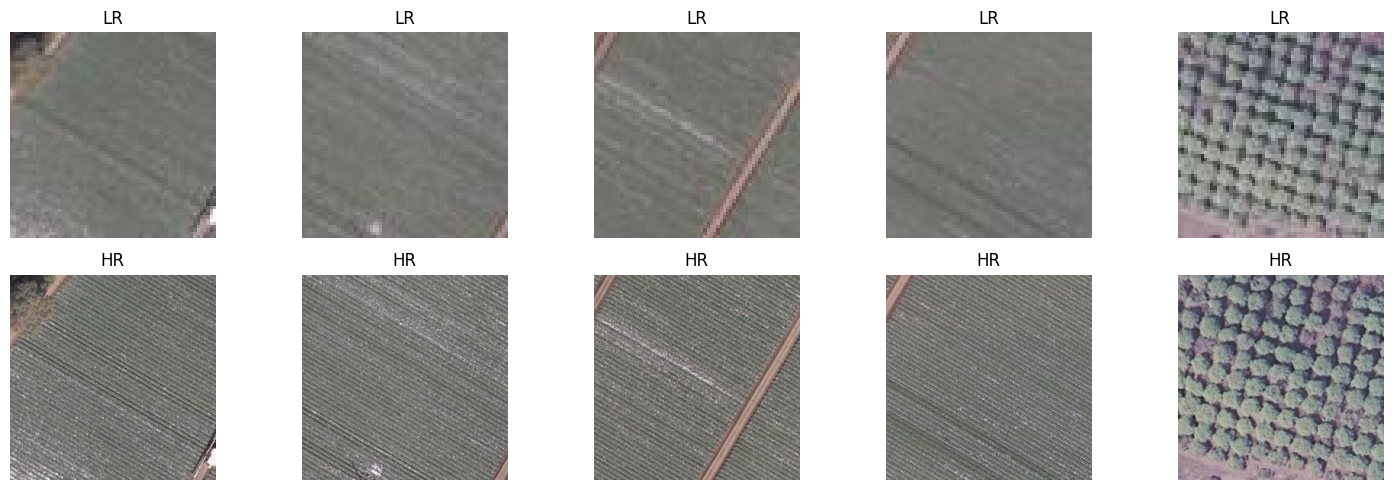

In [3]:
def visualize_pairs():
    train_hr_folder = os.path.join(OUT_FOLDER, 'train', 'HR')
    train_lr_folder = os.path.join(OUT_FOLDER, 'train', 'LR')
    files = sorted(os.listdir(train_hr_folder))[:5]
    plt.figure(figsize=(15, 5))
    for i, file in enumerate(files):
        hr_img = Image.open(os.path.join(train_hr_folder, file))
        lr_img = Image.open(os.path.join(train_lr_folder, file))
        plt.subplot(2, 5, i + 1)
        plt.imshow(lr_img)
        plt.title('LR')
        plt.axis('off')
        plt.subplot(2, 5, i + 6)
        plt.imshow(hr_img)
        plt.title('HR')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

visualize_pairs()

## Step 4: Define Dataset

In [10]:
class SRDataset(Dataset):
    def __init__(self, lr_path, hr_path):
        self.lr_data = torch.load(lr_path)
        self.hr_data = torch.load(hr_path)
    def __len__(self):
        return len(self.lr_data)
    def __getitem__(self, idx):
        return self.lr_data[idx], self.hr_data[idx]

train_dataset = SRDataset(os.path.join(OUT_FOLDER, 'train_LR.pt'), os.path.join(OUT_FOLDER, 'train_HR.pt'))
test_dataset = SRDataset(os.path.join(OUT_FOLDER, 'test_LR.pt'), os.path.join(OUT_FOLDER, 'test_HR.pt'))

## Step 5: ReFDN Model Architecture

In [ ]:
class MultiConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(MultiConv, self).__init__()
        self.conv1x1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, padding=0)
        self.conv3x3 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv5x5 = nn.Conv2d(in_channels, out_channels, kernel_size=5, padding=2)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.conv1x1(x) + self.conv3x3(x) + self.conv5x5(x)
        out = self.bn(out)
        out = self.relu(out)
        return out

    def reparam(self):
        # Simplified re-parameterization to a single 3x3 conv
        conv = nn.Conv2d(self.conv3x3.in_channels, self.conv3x3.out_channels, kernel_size=3, padding=1)
        conv.weight.data = self.conv3x3.weight.data
        conv.bias.data = self.conv3x3.bias.data
        return conv

class ECSA(nn.Module):
    def __init__(self, channels):
        super(ECSA, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=3, padding=1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x)
        y = y.squeeze(-1).transpose(-1, -2)
        y = self.conv(y).transpose(-1, -2).unsqueeze(-1)
        y = self.sigmoid(y)
        return x * y.expand_as(x)

class ReFDB(nn.Module):
    def __init__(self, channels):
        super(ReFDB, self).__init__()
        self.conv1 = MultiConv(channels, channels)
        self.ecsa = ECSA(channels)
        self.conv2 = MultiConv(channels, channels)

    def forward(self, x):
        out = self.conv1(x)
        out = self.ecsa(out)
        out = self.conv2(out)
        return out + x

    def reparam(self):
        reparam_conv1 = self.conv1.reparam()
        reparam_conv2 = self.conv2.reparam()
        return nn.Sequential(reparam_conv1, self.ecsa, reparam_conv2)

class ReFDN(nn.Module):
    def __init__(self, in_channels=3, num_features=48, num_blocks=8, scale=4):
        super(ReFDN, self).__init__()
        self.conv_first = nn.Conv2d(in_channels, num_features, kernel_size=3, padding=1)
        self.body = nn.ModuleList([ReFDB(num_features) for _ in range(num_blocks)])
        self.conv_last = nn.Conv2d(num_features, num_features, kernel_size=3, padding=1)
        self.upsample = nn.Sequential(
            nn.Conv2d(num_features, num_features * (scale ** 2), kernel_size=3, padding=1),
            nn.PixelShuffle(scale)
        )
        self.conv_out = nn.Conv2d(num_features, in_channels, kernel_size=3, padding=1)

    def forward(self, x):
        out = self.conv_first(x)
        for block in self.body:
            out = block(out)
        out = self.conv_last(out)
        out = self.upsample(out)
        out = self.conv_out(out)
        return out

    def reparam(self):
        reparam_model = ReFDN(in_channels=3, num_features=NUM_FEATURES, num_blocks=NUM_BLOCKS, scale=SCALE)
        reparam_model.conv_first.load_state_dict(self.conv_first.state_dict())
        reparam_model.body = nn.ModuleList([block.reparam() for block in self.body])
        reparam_model.conv_last.load_state_dict(self.conv_last.state_dict())
        reparam_model.upsample.load_state_dict(self.upsample.state_dict())
        reparam_model.conv_out.load_state_dict(self.conv_out.state_dict())
        return reparam_model
    
def reparam(self):
    reparam_model = ReFDN(
        in_channels=self.conv_first.in_channels,
        num_features=self.conv_first.out_channels,
        num_blocks=len(self.body),
        scale=int(self.upsample[1].upscale_factor)  # extract scale from PixelShuffle
    )

    # Copy weights
    reparam_model.conv_first.load_state_dict(self.conv_first.state_dict())
    reparam_model.conv_last.load_state_dict(self.conv_last.state_dict())
    reparam_model.upsample.load_state_dict(self.upsample.state_dict())
    reparam_model.conv_out.load_state_dict(self.conv_out.state_dict())

    # Fix: replace body blocks individually
    for i, block in enumerate(self.body):
        reparam_model.body[i] = block.reparam()

    return reparam_model


## Step 6: Training

In [12]:
def train_refdn():
    # Define DataLoaders with num_workers=0 for Windows compatibility
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)

    model = ReFDN(in_channels=3, num_features=NUM_FEATURES, num_blocks=NUM_BLOCKS, scale=SCALE).to(device)
    criterion = nn.L1Loss()
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[15, 25], gamma=0.5)

    best_psnr = 0
    for epoch in range(NUM_EPOCHS):
        model.train()
        train_loss = 0
        try:
            for lr, hr in tqdm.tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS}'):
                lr, hr = lr.to(device), hr.to(device)
                optimizer.zero_grad()
                sr = model(lr)
                loss = criterion(sr, hr)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()
        except RuntimeError as e:
            print(f"DataLoader error: {e}. Ensure num_workers=0 in DataLoader.")
            raise

        scheduler.step()

        # Evaluation
        model.eval()
        psnr, ssim = 0, 0
        with torch.no_grad():
            for lr, hr in test_loader:
                lr, hr = lr.to(device), hr.to(device)
                sr = model(lr)
                sr_np = sr.cpu().numpy().squeeze().transpose(1, 2, 0)
                hr_np = hr.cpu().numpy().squeeze().transpose(1, 2, 0)
                psnr += peak_signal_noise_ratio(hr_np, sr_np, data_range=1.0)
                ssim += structural_similarity(hr_np, sr_np, channel_axis=2, data_range=1.0)

        avg_psnr = psnr / len(test_loader)
        print(f'Epoch {epoch+1}, Loss: {train_loss/len(train_loader):.4f}, PSNR: {avg_psnr:.2f}, SSIM: {ssim/len(test_loader):.4f}')

        # Save best model
        if avg_psnr > best_psnr:
            best_psnr = avg_psnr
            torch.save(model.state_dict(), MODEL_PATH)
            reparam_model = model.reparam()
            torch.save(reparam_model.state_dict(), MODEL_PATH.replace('.pth', '_reparam.pth'))

train_refdn()

Epoch 1/50: 100%|██████████| 105/105 [00:29<00:00,  3.51it/s]


Epoch 1, Loss: 0.1144, PSNR: 20.72, SSIM: 0.4178


Epoch 2/50: 100%|██████████| 105/105 [00:29<00:00,  3.55it/s]


Epoch 2, Loss: 0.0807, PSNR: 20.85, SSIM: 0.4939


Epoch 3/50: 100%|██████████| 105/105 [00:29<00:00,  3.55it/s]


...

Epoch 48, Loss: 0.0450, PSNR: 24.36, SSIM: 0.6382


Epoch 49/50: 100%|██████████| 105/105 [00:29<00:00,  3.56it/s]


Epoch 49, Loss: 0.0450, PSNR: 24.48, SSIM: 0.6394


Epoch 50/50: 100%|██████████| 105/105 [00:29<00:00,  3.56it/s]


Epoch 50, Loss: 0.0447, PSNR: 24.45, SSIM: 0.6373


In [47]:
# === Define required global variables BEFORE calling train_refdn ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUT_FOLDER = r"C:\SR_Project(2ndsem)\DataSet"
MODEL_PATH = os.path.join(OUT_FOLDER, "refdn_checkpoint.pth")
NUM_EPOCHS = 30
BATCH_SIZE = 4
LR = 1e-4
SCALE = 4
NUM_FEATURES = 64
NUM_BLOCKS = 8

# Assuming SRDataset is your custom dataset class and it's already defined
# Replace these lines with actual dataset initialization
train_dataset = SRDataset(os.path.join(OUT_FOLDER, 'train_LR.pt'),
                          os.path.join(OUT_FOLDER, 'train_HR.pt'))
test_dataset = SRDataset(os.path.join(OUT_FOLDER, 'test_LR.pt'),
                         os.path.join(OUT_FOLDER, 'test_HR.pt'))

# === Your train_refdn function remains unchanged ===
# (Paste your train_refdn() function here)

# === Finally, call the function to start training ===
if __name__ == "__main__":
    print("✅ Script starting...")
    train_refdn()  # Or provide a resume_checkpoint path


✅ Script starting...
=== Starting ReFDN Training ===
All required variables defined.
PyTorch version: 2.6.0+cu124
Device: cuda
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3050 Laptop GPU
All dataset files found.
Train loader batches: 420, Test loader batches: 420
Model, criterion, optimizer, and scheduler initialized successfully.
Checkpoint directory created: C:\SR_Project(2ndsem)\DataSet\checkpoints

Starting epoch 1/30


Epoch 1/30:   0%|          | 2/420 [00:00<01:26,  4.85it/s]

Batch 1/420, Loss: 0.6621


Epoch 1/30:   3%|▎         | 12/420 [00:01<00:44,  9.12it/s]

Batch 11/420, Loss: 0.2202


...

Batch 401/420, Loss: 0.0594


Epoch 30/30:  98%|█████████▊| 412/420 [00:44<00:00,  9.13it/s]

Batch 411/420, Loss: 0.0414


Epoch 30/30: 100%|██████████| 420/420 [00:45<00:00,  9.17it/s]


Epoch 30 training completed. Average Loss: 0.0427
Epoch 30, Loss: 0.0427, PSNR: 24.69, SSIM: 0.6495
Saved checkpoint: C:\SR_Project(2ndsem)\DataSet\checkpoints\checkpoint_epoch_30.pth
=== Training completed successfully ===


## Step 7: Testing and Visualization

In [65]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# Define MultiConv (exact match from training code)
class MultiConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(MultiConv, self).__init__()
        self.conv1x1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, padding=0)
        self.conv3x3 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv5x5 = nn.Conv2d(in_channels, out_channels, kernel_size=5, padding=2)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out1 = self.conv1x1(x)
        out2 = self.conv3x3(x)
        out3 = self.conv5x5(x)
        out = out1 + out2 + out3
        out = self.bn(out)
        out = self.relu(out)
        return out

# Define ECSA (exact match from training code)
class ECSA(nn.Module):
    def __init__(self, channels, k_size=3):
        super(ECSA, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k_size, padding=(k_size - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x)
        y = y.squeeze(-1).transpose(-1, -2)
        y = self.conv(y).transpose(-1, -2).unsqueeze(-1)
        y = self.sigmoid(y)
        return x * y.expand_as(x)

# Define ReFDB (exact match from training code)
class ReFDB(nn.Module):
    def __init__(self, num_features):
        super(ReFDB, self).__init__()
        self.multi_conv = MultiConv(num_features, num_features)
        self.ecsa = ECSA(num_features)
        self.conv1 = nn.Conv2d(num_features, num_features, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.multi_conv(x)
        out = self.ecsa(out)
        out = self.conv1(out)
        out = self.relu(out + x)  # Residual connection
        return out

# Define the ReFDN model (exact match from training code)
class ReFDN(nn.Module):
    def __init__(self, in_channels=3, num_features=64, num_blocks=8, scale=4):
        super(ReFDN, self).__init__()
        self.scale = scale
        self.conv1 = nn.Conv2d(in_channels, num_features, kernel_size=3, padding=1)
        self.block = nn.ModuleList([ReFDB(num_features) for _ in range(num_blocks)])
        self.upconv = nn.Sequential(
            nn.Conv2d(num_features, num_features * (scale ** 2), kernel_size=3, padding=1),
            nn.PixelShuffle(scale),
            nn.Conv2d(num_features, in_channels, kernel_size=3, padding=1)
        )

    def forward(self, x):
        x = self.conv1(x)
        for b in self.block:
            x = b(x)
        x = self.upconv(x)
        return x

# Define the test dataset class using .pt files
class TestDataset(Dataset):
    def __init__(self, lr_path, hr_path, transform=None):
        print(f"Attempting to load LR data from: {lr_path}")
        print(f"Attempting to load HR data from: {hr_path}")
        
        # Check directory contents
        lr_dir = os.path.dirname(lr_path)
        hr_dir = os.path.dirname(hr_path)
        print(f"Contents of LR directory ({lr_dir}): {os.listdir(lr_dir) if os.path.exists(lr_dir) else 'Directory not found'}")
        print(f"Contents of HR directory ({hr_dir}): {os.listdir(hr_dir) if os.path.exists(hr_dir) else 'Directory not found'}")
        
        if not os.path.exists(lr_path):
            raise FileNotFoundError(f"LR file not found at: {lr_path}")
        if not os.path.exists(hr_path):
            raise FileNotFoundError(f"HR file not found at: {hr_path}")
        
        self.lr_data = torch.load(lr_path)
        self.hr_data = torch.load(hr_path)
        self.transform = transform
        
        print(f"LR data type: {type(self.lr_data)}")
        print(f"HR data type: {type(self.hr_data)}")
        print(f"LR data shape: {self.lr_data.shape}")
        print(f"HR data shape: {self.hr_data.shape}")
        
        # Validate shapes of all images
        for i in range(len(self.lr_data)):
            lr_shape = self.lr_data[i].shape
            hr_shape = self.hr_data[i].shape
            if lr_shape[0] != 3 or hr_shape[0] != 3:
                print(f"Warning: Sample {i} has unexpected channel dimension - LR: {lr_shape}, HR: {hr_shape}")
            if lr_shape[1] < 7 or lr_shape[2] < 7:
                print(f"Warning: Sample {i} LR image too small: {lr_shape}")
            if hr_shape[1] < 7 or hr_shape[2] < 7:
                print(f"Warning: Sample {i} HR image too small: {hr_shape}")
        
        assert len(self.lr_data) == len(self.hr_data), f"LR and HR data lengths mismatch: {len(self.lr_data)} vs {len(self.hr_data)}"
        print(f"Loaded {len(self.lr_data)} LR images and {len(self.hr_data)} HR images")

    def __len__(self):
        return len(self.lr_data)

    def __getitem__(self, idx):
        lr_image = self.lr_data[idx]
        hr_image = self.hr_data[idx]
        print(f"Sample {idx}: LR image shape: {lr_image.shape}, HR image shape: {hr_image.shape}")
        print(f"Sample {idx}: LR image dtype: {lr_image.dtype}, HR image dtype: {hr_image.dtype}")
        if self.transform:
            lr_image = self.transform(lr_image)
            hr_image = self.transform(hr_image)
        return lr_image, hr_image

# Define the testing and visualization function
def test_and_visualize(model_path, test_dataset, device, scale=4, num_features=64, num_blocks=8, save_folder=None):
    print(f"\n🔍 Testing: {os.path.basename(model_path)}")

    # Load model
    model = ReFDN(in_channels=3, num_features=num_features, num_blocks=num_blocks, scale=scale).to(device)
    
    # Debug: Print model's expected state_dict keys
    model_keys = list(model.state_dict().keys())
    print(f"Model's expected state_dict keys (first 10): {model_keys[:10]}")
    print(f"Total number of expected keys: {len(model_keys)}")
    
    # Test forward pass with a dummy input
    try:
        dummy_input = torch.randn(1, 3, 64, 64).to(device)
        print(f"Dummy input shape: {dummy_input.shape}, device: {dummy_input.device}")
        with torch.no_grad():
            dummy_output = model(dummy_input)
        print(f"Dummy output shape: {dummy_output.shape}")
    except Exception as e:
        print(f"❌ Error during dummy forward pass: {e}")
        return
    
    # Verify checkpoint file exists
    checkpoint_dir = os.path.dirname(model_path)
    print(f"Contents of checkpoint directory ({checkpoint_dir}): {os.listdir(checkpoint_dir) if os.path.exists(checkpoint_dir) else 'Directory not found'}")
    if not os.path.exists(model_path):
        print(f"❌ Checkpoint file not found at: {model_path}")
        return
    
    try:
        # Load the checkpoint
        print(f"Loading checkpoint from: {model_path}")
        checkpoint = torch.load(model_path, map_location=device, weights_only=False)
        print("Checkpoint keys:", list(checkpoint.keys()))
        
        # Load the state_dict with strict=False to identify mismatches
        if 'model_state_dict' in checkpoint:
            checkpoint_keys = list(checkpoint['model_state_dict'].keys())
            print(f"Checkpoint model_state_dict keys (first 10): {checkpoint_keys[:10]}")
            print(f"Total number of checkpoint keys: {len(checkpoint_keys)}")
            
            # Check for missing and unexpected keys
            missing_keys, unexpected_keys = model.load_state_dict(checkpoint['model_state_dict'], strict=False)
            if missing_keys:
                print(f"Missing keys in model: {missing_keys}")
            if unexpected_keys:
                print(f"Unexpected keys in checkpoint: {unexpected_keys}")
            if missing_keys or unexpected_keys:
                print("⚠️ State dictionary mismatch detected. Proceeding with partial load for debugging...")
            else:
                print("✅ State dictionary loaded perfectly.")
        else:
            raise KeyError("Checkpoint does not contain 'model_state_dict' key")
    except Exception as e:
        print(f"❌ Error loading checkpoint: {e}")
        return

    model.eval()
    psnr_list = []
    ssim_list = []
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

    # Limit to first 1 sample for debugging
    max_samples = 1
    print(f"Processing {max_samples} sample for debugging...")

    for i, (lr, hr) in enumerate(test_loader):
        if i >= max_samples:
            break
            
        print(f"Batch {i+1}: LR shape: {lr.shape}, HR shape: {hr.shape}")
        print(f"Batch {i+1}: LR device: {lr.device}, HR device: {hr.device}")
        lr = lr.to(device)
        hr_np = hr.squeeze().cpu().numpy().transpose(1, 2, 0)  # Convert to HWC for metrics
        print(f"Batch {i+1}: HR (numpy) shape: {hr_np.shape}")

        with torch.no_grad():
            sr = model(lr).squeeze().cpu().numpy().transpose(1, 2, 0)  # Convert to HWC
            print(f"Batch {i+1}: SR shape: {sr.shape}")

        sr = np.clip(sr, 0, 1)
        hr_np = np.clip(hr_np, 0, 1)

        # Validate image sizes for SSIM
        min_dim = min(hr_np.shape[0], hr_np.shape[1], sr.shape[0], sr.shape[1])
        if min_dim < 7:
            print(f"❌ Image too small for SSIM: HR shape {hr_np.shape}, SR shape {sr.shape}")
            continue
        
        # Dynamically set win_size to be smaller than the smallest dimension
        win_size = min(11, min_dim - 1 if min_dim % 2 == 0 else min_dim)  # Ensure win_size is odd
        win_size = max(3, win_size)  # Ensure win_size is at least 3
        print(f"Using win_size={win_size} for SSIM calculation")

        psnr = peak_signal_noise_ratio(hr_np, sr, data_range=1)
        ssim = structural_similarity(hr_np, sr, channel_axis=2, data_range=1, win_size=win_size)

        psnr_list.append(psnr)
        ssim_list.append(ssim)

        print(f"[{i+1}/{max_samples}] PSNR: {psnr:.2f} | SSIM: {ssim:.4f}")

        # Visualization
        fig, axs = plt.subplots(1, 3, figsize=(15, 5))
        axs[0].imshow(hr_np)
        axs[0].set_title("Ground Truth (HR)")
        axs[1].imshow(lr.squeeze().cpu().numpy().transpose(1, 2, 0))
        axs[1].set_title("Low-Resolution Input (LR)")
        axs[2].imshow(sr)
        axs[2].set_title("Super-Resolved Output (SR)")
        for ax in axs:
            ax.axis("off")

        if save_folder:
            os.makedirs(save_folder, exist_ok=True)
            plt.savefig(os.path.join(save_folder, f"result_{i+1}.png"))
        plt.close(fig)  # Close figure to free memory

    print(f"\n📊 Average PSNR (first {max_samples} samples): {np.mean(psnr_list):.2f} ± {np.std(psnr_list):.2f}")
    print(f"📊 Average SSIM (first {max_samples} samples): {np.mean(ssim_list):.4f} ± {np.std(ssim_list):.4f}")

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Define paths
checkpoint_path = r"C:\SR_Project(2ndsem)\DataSet\checkpoints\checkpoint_epoch_30.pth"
lr_path = r"C:\SR_Project(2ndsem)\DataSet\test_LR.pt"
hr_path = r"C:\SR_Project(2ndsem)\DataSet\test_HR.pt"
save_folder = r"C:\SR_Project(2ndsem)\DataSet\results"

# Define transformations
transform = transforms.Compose([
    transforms.Lambda(lambda x: x if x.dtype == torch.float32 else x.float() / 255.0)
])

# Prepare test dataset
try:
    test_dataset = TestDataset(lr_path=lr_path, hr_path=hr_path, transform=transform)
except Exception as e:
    print(f"❌ Error loading test dataset: {e}")
    exit(1)

# Run testing and visualization
test_and_visualize(
    model_path=checkpoint_path,
    test_dataset=test_dataset,
    device=device,
    scale=4,
    num_features=64,
    num_blocks=8,
    save_folder=save_folder
)

Using device: cuda
Attempting to load LR data from: C:\SR_Project(2ndsem)\DataSet\test_LR.pt
Attempting to load HR data from: C:\SR_Project(2ndsem)\DataSet\test_HR.pt
Contents of LR directory (C:\SR_Project(2ndsem)\DataSet): ['checkpoints', 'refdn_checkpoint.pth', 'refdn_checkpoint_reparam.pth', 'test', 'test_HR.pt', 'test_LR.pt', 'train', 'train_HR.npy', 'train_HR.pt', 'train_LR.npy', 'train_LR.pt']
Contents of HR directory (C:\SR_Project(2ndsem)\DataSet): ['checkpoints', 'refdn_checkpoint.pth', 'refdn_checkpoint_reparam.pth', 'test', 'test_HR.pt', 'test_LR.pt', 'train', 'train_HR.npy', 'train_HR.pt', 'train_LR.npy', 'train_LR.pt']
LR data type: <class 'torch.Tensor'>
HR data type: <class 'torch.Tensor'>
LR data shape: torch.Size([420, 3, 64, 64])
HR data shape: torch.Size([420, 3, 256, 256])
Loaded 420 LR images and 420 HR images

🔍 Testing: checkpoint_epoch_30.pth
Model's expected state_dict keys (first 10): ['conv1.weight', 'conv1.bias', 'block.0.multi_conv.conv1x1.weight', 'block.

In [67]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# Define MultiConv (exact match from training code)
class MultiConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(MultiConv, self).__init__()
        self.conv1x1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, padding=0)
        self.conv3x3 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv5x5 = nn.Conv2d(in_channels, out_channels, kernel_size=5, padding=2)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out1 = self.conv1x1(x)
        out2 = self.conv3x3(x)
        out3 = self.conv5x5(x)
        out = out1 + out2 + out3
        out = self.bn(out)
        out = self.relu(out)
        return out

# Define ECSA (exact match from training code)
class ECSA(nn.Module):
    def __init__(self, channels, k_size=3):
        super(ECSA, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k_size, padding=(k_size - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x)
        y = y.squeeze(-1).transpose(-1, -2)
        y = self.conv(y).transpose(-1, -2).unsqueeze(-1)
        y = self.sigmoid(y)
        return x * y.expand_as(x)

# Define ReFDB (exact match from training code)
class ReFDB(nn.Module):
    def __init__(self, num_features):
        super(ReFDB, self).__init__()
        self.multi_conv = MultiConv(num_features, num_features)
        self.ecsa = ECSA(num_features)
        self.conv1 = nn.Conv2d(num_features, num_features, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.multi_conv(x)
        out = self.ecsa(out)
        out = self.conv1(out)
        out = self.relu(out + x)  # Residual connection
        return out

# Define the ReFDN model (exact match from training code)
class ReFDN(nn.Module):
    def __init__(self, in_channels=3, num_features=64, num_blocks=8, scale=4):
        super(ReFDN, self).__init__()
        self.scale = scale
        self.conv1 = nn.Conv2d(in_channels, num_features, kernel_size=3, padding=1)
        self.block = nn.ModuleList([ReFDB(num_features) for _ in range(num_blocks)])
        self.upconv = nn.Sequential(
            nn.Conv2d(num_features, num_features * (scale ** 2), kernel_size=3, padding=1),
            nn.PixelShuffle(scale),
            nn.Conv2d(num_features, in_channels, kernel_size=3, padding=1)
        )

    def forward(self, x):
        x = self.conv1(x)
        for b in self.block:
            x = b(x)
        x = self.upconv(x)
        return x

# Define the test dataset class using .pt files
class TestDataset(Dataset):
    def __init__(self, lr_path, hr_path, transform=None):
        print(f"Attempting to load LR data from: {lr_path}")
        print(f"Attempting to load HR data from: {hr_path}")
        
        # Check directory contents
        lr_dir = os.path.dirname(lr_path)
        hr_dir = os.path.dirname(hr_path)
        print(f"Contents of LR directory ({lr_dir}): {os.listdir(lr_dir) if os.path.exists(lr_dir) else 'Directory not found'}")
        print(f"Contents of HR directory ({hr_dir}): {os.listdir(hr_dir) if os.path.exists(hr_dir) else 'Directory not found'}")
        
        if not os.path.exists(lr_path):
            raise FileNotFoundError(f"LR file not found at: {lr_path}")
        if not os.path.exists(hr_path):
            raise FileNotFoundError(f"HR file not found at: {hr_path}")
        
        self.lr_data = torch.load(lr_path)
        self.hr_data = torch.load(hr_path)
        self.transform = transform
        
        print(f"LR data type: {type(self.lr_data)}")
        print(f"HR data type: {type(self.hr_data)}")
        print(f"LR data shape: {self.lr_data.shape}")
        print(f"HR data shape: {self.hr_data.shape}")
        
        # Validate shapes and ranges of all images
        for i in range(len(self.lr_data)):
            lr_shape = self.lr_data[i].shape
            hr_shape = self.hr_data[i].shape
            if lr_shape[0] != 3 or hr_shape[0] != 3:
                print(f"Warning: Sample {i} has unexpected channel dimension - LR: {lr_shape}, HR: {hr_shape}")
            if lr_shape[1] < 7 or lr_shape[2] < 7:
                print(f"Warning: Sample {i} LR image too small: {lr_shape}")
            if hr_shape[1] < 7 or hr_shape[2] < 7:
                print(f"Warning: Sample {i} HR image too small: {hr_shape}")
            lr_min, lr_max = self.lr_data[i].min().item(), self.lr_data[i].max().item()
            hr_min, hr_max = self.hr_data[i].min().item(), self.hr_data[i].max().item()
            print(f"Sample {i}: LR min/max: {lr_min:.2f}/{lr_max:.2f}, HR min/max: {hr_min:.2f}/{hr_max:.2f}")
        
        assert len(self.lr_data) == len(self.hr_data), f"LR and HR data lengths mismatch: {len(self.lr_data)} vs {len(self.hr_data)}"
        print(f"Loaded {len(self.lr_data)} LR images and {len(self.hr_data)} HR images")

    def __len__(self):
        return len(self.lr_data)

    def __getitem__(self, idx):
        lr_image = self.lr_data[idx]
        hr_image = self.hr_data[idx]
        print(f"Sample {idx}: LR image shape: {lr_image.shape}, HR image shape: {hr_image.shape}")
        print(f"Sample {idx}: LR image dtype: {lr_image.dtype}, HR image dtype: {hr_image.dtype}")
        if self.transform:
            lr_image = self.transform(lr_image)
            hr_image = self.transform(hr_image)
        return lr_image, hr_image

# Define the testing and visualization function
def test_and_visualize(model_path, test_dataset, device, scale=4, num_features=64, num_blocks=8, save_folder=None, max_samples=10):
    print(f"\n🔍 Testing: {os.path.basename(model_path)}")

    # Load model
    model = ReFDN(in_channels=3, num_features=num_features, num_blocks=num_blocks, scale=scale).to(device)
    
    # Debug: Print model's expected state_dict keys
    model_keys = list(model.state_dict().keys())
    print(f"Model's expected state_dict keys (first 10): {model_keys[:10]}")
    print(f"Total number of expected keys: {len(model_keys)}")
    
    # Test forward pass with a dummy input
    try:
        dummy_input = torch.randn(1, 3, 64, 64).to(device)
        print(f"Dummy input shape: {dummy_input.shape}, device: {dummy_input.device}")
        with torch.no_grad():
            dummy_output = model(dummy_input)
        print(f"Dummy output shape: {dummy_output.shape}")
    except Exception as e:
        print(f"❌ Error during dummy forward pass: {e}")
        return
    
    # Verify checkpoint file exists
    checkpoint_dir = os.path.dirname(model_path)
    print(f"Contents of checkpoint directory ({checkpoint_dir}): {os.listdir(checkpoint_dir) if os.path.exists(checkpoint_dir) else 'Directory not found'}")
    if not os.path.exists(model_path):
        print(f"❌ Checkpoint file not found at: {model_path}")
        return
    
    try:
        # Load the checkpoint
        print(f"Loading checkpoint from: {model_path}")
        checkpoint = torch.load(model_path, map_location=device, weights_only=False)
        print("Checkpoint keys:", list(checkpoint.keys()))
        
        # Load the state_dict with strict=False to identify mismatches
        if 'model_state_dict' in checkpoint:
            checkpoint_keys = list(checkpoint['model_state_dict'].keys())
            print(f"Checkpoint model_state_dict keys (first 10): {checkpoint_keys[:10]}")
            print(f"Total number of checkpoint keys: {len(checkpoint_keys)}")
            
            # Check for missing and unexpected keys
            missing_keys, unexpected_keys = model.load_state_dict(checkpoint['model_state_dict'], strict=False)
            if missing_keys:
                print(f"Missing keys in model: {missing_keys}")
            if unexpected_keys:
                print(f"Unexpected keys in checkpoint: {unexpected_keys}")
            if missing_keys or unexpected_keys:
                print("⚠️ State dictionary mismatch detected. Proceeding with partial load for debugging...")
            else:
                print("✅ State dictionary loaded perfectly.")
        else:
            raise KeyError("Checkpoint does not contain 'model_state_dict' key")
    except Exception as e:
        print(f"❌ Error loading checkpoint: {e}")
        return

    model.eval()
    psnr_list = []
    ssim_list = []
    mae_list = []
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

    # Limit to max_samples (default 10)
    max_samples = min(max_samples, len(test_dataset))
    print(f"Processing {max_samples} samples for visualization...")

    for i, (lr, hr) in enumerate(test_loader):
        if i >= max_samples:
            break
            
        print(f"Batch {i+1}: LR shape: {lr.shape}, HR shape: {hr.shape}")
        print(f"Batch {i+1}: LR device: {lr.device}, HR device: {hr.device}")
        lr = lr.to(device)
        hr_np = hr.squeeze().cpu().numpy().transpose(1, 2, 0)  # Convert to HWC for metrics
        print(f"Batch {i+1}: HR (numpy) shape: {hr_np.shape}")

        with torch.no_grad():
            sr_tensor = model(lr).squeeze().cpu()  # Keep as tensor for MAE
            sr_raw = sr_tensor.numpy().transpose(1, 2, 0)  # Raw SR for visualization
            print(f"Batch {i+1}: SR (raw) shape: {sr_raw.shape}")
            print(f"Batch {i+1}: SR (raw) min/max: {sr_raw.min():.2f}/{sr_raw.max():.2f}")
            sr = np.clip(sr_raw, 0, 1)  # Clipped SR for metrics and visualization
            print(f"Batch {i+1}: SR (clipped) shape: {sr.shape}")
            print(f"Batch {i+1}: SR (clipped) min/max: {sr.min():.2f}/{sr.max():.2f}")

        hr_np = np.clip(hr_np, 0, 1)

        # Compute MAE between SR and HR
        mae = np.mean(np.abs(sr - hr_np))
        mae_list.append(mae)

        # Validate image sizes for SSIM
        min_dim = min(hr_np.shape[0], hr_np.shape[1], sr.shape[0], sr.shape[1])
        if min_dim < 7:
            print(f"❌ Image too small for SSIM: HR shape {hr_np.shape}, SR shape {sr.shape}")
            continue
        
        # Dynamically set win_size
        win_size = min(11, min_dim - 1 if min_dim % 2 == 0 else min_dim)  # Ensure win_size is odd
        win_size = max(3, win_size)  # Ensure win_size is at least 3
        print(f"Using win_size={win_size} for SSIM calculation")

        psnr = peak_signal_noise_ratio(hr_np, sr, data_range=1)
        ssim = structural_similarity(hr_np, sr, channel_axis=2, data_range=1, win_size=win_size)

        psnr_list.append(psnr)
        ssim_list.append(ssim)

        print(f"[{i+1}/{max_samples}] PSNR: {psnr:.2f} | SSIM: {ssim:.4f} | MAE: {mae:.4f}")

        # Visualization with enhanced details
        fig, axs = plt.subplots(1, 4, figsize=(24, 6))
        
        # Ground Truth (HR)
        axs[0].imshow(hr_np)
        axs[0].set_title(f"Ground Truth (HR)\n{hr_np.shape[0]}x{hr_np.shape[1]}")
        
        # Low-Resolution Input (LR)
        lr_np = lr.squeeze().cpu().numpy().transpose(1, 2, 0)
        axs[1].imshow(lr_np)
        axs[1].set_title(f"Low-Resolution Input (LR)\n{lr_np.shape[0]}x{lr_np.shape[1]}")
        
        # Super-Resolved Output (SR, clipped)
        axs[2].imshow(sr)
        axs[2].set_title(f"Super-Resolved (Clipped)\nPSNR: {psnr:.2f}, SSIM: {ssim:.4f}, MAE: {mae:.4f}\n{sr.shape[0]}x{sr.shape[1]}")
        
        # Super-Resolved Output (SR, raw)
        sr_raw_display = np.clip(sr_raw, 0, 1)  # Clip for display purposes only
        axs[3].imshow(sr_raw_display)
        axs[3].set_title(f"Super-Resolved (Raw)\nMin/Max: {sr_raw.min():.2f}/{sr_raw.max():.2f}\n{sr_raw.shape[0]}x{sr_raw.shape[1]}")

        for ax in axs:
            ax.axis("off")

        # Add zoomed-in inset for HR, SR (clipped), and SR (raw)
        zoom_region = (slice(0, 64), slice(0, 64))
        
        # Inset for HR
        axins_hr = inset_axes(axs[0], width="30%", height="30%", loc="lower right")
        axins_hr.imshow(hr_np[zoom_region])
        axins_hr.set_xticks([])
        axins_hr.set_yticks([])
        
        # Inset for SR (clipped)
        axins_sr = inset_axes(axs[2], width="30%", height="30%", loc="lower right")
        axins_sr.imshow(sr[zoom_region])
        axins_sr.set_xticks([])
        axins_sr.set_yticks([])

        # Inset for SR (raw)
        axins_sr_raw = inset_axes(axs[3], width="30%", height="30%", loc="lower right")
        axins_sr_raw.imshow(sr_raw_display[zoom_region])
        axins_sr_raw.set_xticks([])
        axins_sr_raw.set_yticks([])

        if save_folder:
            os.makedirs(save_folder, exist_ok=True)
            save_path = os.path.join(save_folder, f"result_{i+1}.png")
            plt.savefig(save_path)
            print(f"Saved visualization for sample {i+1} to {save_path}")
        plt.close(fig)  # Close figure to free memory

    print(f"\n📊 Average PSNR (first {max_samples} samples): {np.mean(psnr_list):.2f} ± {np.std(psnr_list):.2f}")
    print(f"📊 Average SSIM (first {max_samples} samples): {np.mean(ssim_list):.4f} ± {np.std(ssim_list):.4f}")
    print(f"📊 Average MAE (first {max_samples} samples): {np.mean(mae_list):.4f} ± {np.std(mae_list):.4f}")

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Define paths
checkpoint_path = r"C:\SR_Project(2ndsem)\DataSet\checkpoints\checkpoint_epoch_30.pth"
lr_path = r"C:\SR_Project(2ndsem)\DataSet\test_LR.pt"
hr_path = r"C:\SR_Project(2ndsem)\DataSet\test_HR.pt"
save_folder = r"C:\SR_Project(2ndsem)\DataSet\results"

# Define transformations
transform = transforms.Compose([
    transforms.Lambda(lambda x: x if x.dtype == torch.float32 else x.float() / 255.0)
])

# Prepare test dataset
try:
    test_dataset = TestDataset(lr_path=lr_path, hr_path=hr_path, transform=transform)
except Exception as e:
    print(f"❌ Error loading test dataset: {e}")
    exit(1)

# Run testing and visualization
test_and_visualize(
    model_path=checkpoint_path,
    test_dataset=test_dataset,
    device=device,
    scale=4,
    num_features=64,
    num_blocks=8,
    save_folder=save_folder,
    max_samples=10  # Visualize first 10 samples
)

Using device: cuda
Attempting to load LR data from: C:\SR_Project(2ndsem)\DataSet\test_LR.pt
Attempting to load HR data from: C:\SR_Project(2ndsem)\DataSet\test_HR.pt
Contents of LR directory (C:\SR_Project(2ndsem)\DataSet): ['checkpoints', 'refdn_checkpoint.pth', 'refdn_checkpoint_reparam.pth', 'results', 'test', 'test_HR.pt', 'test_LR.pt', 'train', 'train_HR.npy', 'train_HR.pt', 'train_LR.npy', 'train_LR.pt']
Contents of HR directory (C:\SR_Project(2ndsem)\DataSet): ['checkpoints', 'refdn_checkpoint.pth', 'refdn_checkpoint_reparam.pth', 'results', 'test', 'test_HR.pt', 'test_LR.pt', 'train', 'train_HR.npy', 'train_HR.pt', 'train_LR.npy', 'train_LR.pt']
LR data type: <class 'torch.Tensor'>
HR data type: <class 'torch.Tensor'>
LR data shape: torch.Size([420, 3, 64, 64])
HR data shape: torch.Size([420, 3, 256, 256])
Sample 0: LR min/max: 0.38/0.57, HR min/max: 0.12/0.78
Sample 1: LR min/max: 0.36/0.57, HR min/max: 0.05/0.95
Sample 2: LR min/max: 0.00/0.78, HR min/max: 0.00/0.85
Sample 3

In [68]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import numpy as np
import matplotlib.pyplot as plt

# Define MultiConv
class MultiConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(MultiConv, self).__init__()
        self.conv1x1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, padding=0)
        self.conv3x3 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv5x5 = nn.Conv2d(in_channels, out_channels, kernel_size=5, padding=2)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out1 = self.conv1x1(x)
        out2 = self.conv3x3(x)
        out3 = self.conv5x5(x)
        out = out1 + out2 + out3
        out = self.bn(out)
        out = self.relu(out)
        return out

# Define ECSA
class ECSA(nn.Module):
    def __init__(self, channels, k_size=3):
        super(ECSA, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k_size, padding=(k_size - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x)
        y = y.squeeze(-1).transpose(-1, -2)
        y = self.conv(y).transpose(-1, -2).unsqueeze(-1)
        y = self.sigmoid(y)
        return x * y.expand_as(x)

# Define ReFDB
class ReFDB(nn.Module):
    def __init__(self, num_features):
        super(ReFDB, self).__init__()
        self.multi_conv = MultiConv(num_features, num_features)
        self.ecsa = ECSA(num_features)
        self.conv1 = nn.Conv2d(num_features, num_features, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.multi_conv(x)
        out = self.ecsa(out)
        out = self.conv1(out)
        out = self.relu(out + x)  # Residual connection
        return out

# Define the ReFDN model
class ReFDN(nn.Module):
    def __init__(self, in_channels=3, num_features=64, num_blocks=8, scale=4):
        super(ReFDN, self).__init__()
        self.scale = scale
        self.conv1 = nn.Conv2d(in_channels, num_features, kernel_size=3, padding=1)
        self.block = nn.ModuleList([ReFDB(num_features) for _ in range(num_blocks)])
        self.upconv = nn.Sequential(
            nn.Conv2d(num_features, num_features * (scale ** 2), kernel_size=3, padding=1),
            nn.PixelShuffle(scale),
            nn.Conv2d(num_features, in_channels, kernel_size=3, padding=1)
        )

    def forward(self, x):
        x = self.conv1(x)
        for b in self.block:
            x = b(x)
        x = self.upconv(x)
        return x

# Define VGG-based perceptual loss
class PerceptualLoss(nn.Module):
    def __init__(self, device):
        super(PerceptualLoss, self).__init__()
        vgg = models.vgg16(pretrained=True).features.to(device).eval()
        for param in vgg.parameters():
            param.requires_grad = False
        self.vgg = vgg
        self.layers = {'3': 'relu1_2', '8': 'relu2_2', '15': 'relu3_3'}
        self.criterion = nn.MSELoss()

    def forward(self, x, y):
        loss = 0
        x_vgg, y_vgg = x, y
        for i, layer in enumerate(self.vgg):
            x_vgg = layer(x_vgg)
            y_vgg = layer(y_vgg)
            if str(i) in self.layers:
                loss += self.criterion(x_vgg, y_vgg)
            if str(i) == '15':
                break
        return loss

# Define the training dataset class
class TrainDataset(Dataset):
    def __init__(self, lr_path, hr_path, transform=None):
        print(f"Loading training LR data from: {lr_path}")
        print(f"Loading training HR data from: {hr_path}")
        self.lr_data = torch.load(lr_path)
        self.hr_data = torch.load(hr_path)
        self.transform = transform
        print(f"Training LR data shape: {self.lr_data.shape}")
        print(f"Training HR data shape: {self.hr_data.shape}")
        assert len(self.lr_data) == len(self.hr_data), f"LR and HR data lengths mismatch: {len(self.lr_data)} vs {len(self.hr_data)}"

    def __len__(self):
        return len(self.lr_data)

    def __getitem__(self, idx):
        lr_image = self.lr_data[idx]
        hr_image = self.hr_data[idx]
        if self.transform:
            lr_image = self.transform(lr_image)
            hr_image = self.transform(hr_image)
        return lr_image, hr_image

# Training function
def train_model(model, train_loader, device, num_epochs=100, save_folder=None):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)
    criterion_mse = nn.MSELoss()
    perceptual_loss = PerceptualLoss(device)

    for epoch in range(num_epochs):
        running_loss = 0.0
        for i, (lr, hr) in enumerate(train_loader):
            lr, hr = lr.to(device), hr.to(device)

            optimizer.zero_grad()
            sr = model(lr)
            
            # Compute combined loss
            mse_loss = criterion_mse(sr, hr)
            perc_loss = perceptual_loss(sr, hr)
            loss = mse_loss + 0.1 * perc_loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            if (i + 1) % 10 == 0:
                print(f"Epoch [{epoch+1}/{num_epochs}] Batch [{i+1}/{len(train_loader)}] Loss: {loss.item():.4f}")

        scheduler.step()
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}] Average Loss: {avg_loss:.4f}")

        # Save checkpoint every 10 epochs
        if (epoch + 1) % 10 == 0 and save_folder:
            os.makedirs(save_folder, exist_ok=True)
            checkpoint_path = os.path.join(save_folder, f"checkpoint_epoch_{epoch+1}.pth")
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'loss': avg_loss,
            }, checkpoint_path)
            print(f"Saved checkpoint to {checkpoint_path}")

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Define paths
train_lr_path = r"C:\SR_Project(2ndsem)\DataSet\train_LR.pt"
train_hr_path = r"C:\SR_Project(2ndsem)\DataSet\train_HR.pt"
checkpoint_folder = r"C:\SR_Project(2ndsem)\DataSet\checkpoints"

# Define transformations
transform = transforms.Compose([
    transforms.Lambda(lambda x: x / 255.0)  # Normalize to [0, 1]
])

# Prepare training dataset
try:
    train_dataset = TrainDataset(lr_path=train_lr_path, hr_path=train_hr_path, transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
except Exception as e:
    print(f"❌ Error loading training dataset: {e}")
    exit(1)

# Initialize model
model = ReFDN(in_channels=3, num_features=64, num_blocks=8, scale=4).to(device)

# Train the model
train_model(
    model=model,
    train_loader=train_loader,
    device=device,
    num_epochs=100,
    save_folder=checkpoint_folder
)

Using device: cuda
Loading training LR data from: C:\SR_Project(2ndsem)\DataSet\train_LR.pt
Loading training HR data from: C:\SR_Project(2ndsem)\DataSet\train_HR.pt
Training LR data shape: torch.Size([1680, 3, 64, 64])
Training HR data shape: torch.Size([1680, 3, 256, 256])


c:\Users\Laxmi Prajapati\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Laxmi Prajapati\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\Laxmi Prajapati/.cache\torch\hub\checkpoints\vgg16-397923af.pth
100%|██████████| 528M/528M [00:59<00:00, 9.33MB/s] 


Epoch [1/100] Batch [10/105] Loss: 0.0867
Epoch [1/100] Batch [20/105] Loss: 0.0425
Epoch [1/100] Batch [30/105] Loss: 0.0211
Epoch [1/100] Batch [40/105] Loss: 0.0113
Epoch [1/100] Batch [50/105] Loss: 0.0138
Epoch [1/100] Batch [60/105] Loss: 0.0090
Epoch [1/100] Batch [70/105] Loss: 0.0095
Epoch [1/100] Batch [80/105] Loss: 0.0057
Epoch [1/100] Batch [90/105] Loss: 0.0040
Epoch [1/100] Batch [100/105] Loss: 0.0031
Epoch [1/100] Average Loss: 0.0320
Epoch [2/100] Batch [10/105] Loss: 0.0023
Epoch [2/100] Batch [20/105] Loss: 0.0019
Epoch [2/100] Batch [30/105] Loss: 0.0015
Epoch [2/100] Batch [40/105] Loss: 0.0012
Epoch [2/100] Batch [50/105] Loss: 0.0011
Epoch [2/100] Batch [60/105] Loss: 0.0009
Epoch [2/100] Batch [70/105] Loss: 0.0008
Epoch [2/100] Batch [80/105] Loss: 0.0007
Epoch [2/100] Batch [90/105] Loss: 0.0006
Epoch [2/100] Batch [100/105] Loss: 0.0006
Epoch [2/100] Average Loss: 0.0012
Epoch [3/100] Batch [10/105] Loss: 0.0005
Epoch [3/100] Batch [20/105] Loss: 0.0005
Epoc

KeyboardInterrupt: 

In [74]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Define MultiConv
class MultiConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(MultiConv, self).__init__()
        self.conv1x1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, padding=0)
        self.conv3x3 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv5x5 = nn.Conv2d(in_channels, out_channels, kernel_size=5, padding=2)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out1 = self.conv1x1(x)
        out2 = self.conv3x3(x)
        out3 = self.conv5x5(x)
        out = out1 + out2 + out3
        out = self.bn(out)
        out = self.relu(out)
        return out

# Define ECSA
class ECSA(nn.Module):
    def __init__(self, channels, k_size=3):
        super(ECSA, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k_size, padding=(k_size - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x)
        y = y.squeeze(-1).transpose(-1, -2)
        y = self.conv(y).transpose(-1, -2).unsqueeze(-1)
        y = self.sigmoid(y)
        return x * y.expand_as(x)

# Define ReFDB
class ReFDB(nn.Module):
    def __init__(self, num_features):
        super(ReFDB, self).__init__()
        self.conv1 = MultiConv(num_features, num_features)
        self.ecsa = ECSA(num_features)
        self.conv2 = nn.Conv2d(num_features, num_features, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.conv1(x)
        out = self.ecsa(out)
        out = self.conv2(out)
        out = self.relu(out + x)
        return out

# Define ReFDN
class ReFDN(nn.Module):
    def __init__(self, in_channels=3, num_features=64, num_blocks=8, scale=4):
        super(ReFDN, self).__init__()
        self.scale = scale
        self.conv_first = nn.Conv2d(in_channels, num_features, kernel_size=3, padding=1)
        self.body = nn.ModuleList([ReFDB(num_features) for _ in range(num_blocks)])
        self.conv_after_body = nn.Conv2d(num_features, num_features, kernel_size=3, padding=1)
        self.upsample = nn.Sequential(
            nn.Conv2d(num_features, num_features * (scale ** 2), kernel_size=3, padding=1),
            nn.PixelShuffle(scale),
            nn.Conv2d(num_features, in_channels, kernel_size=3, padding=1)
        )

    def forward(self, x):
        x = self.conv_first(x)
        for b in self.body:
            x = b(x)
        x = self.conv_after_body(x)
        x = self.upsample(x)
        return x

# Define Dataset
class SRDataset(Dataset):
    def __init__(self, lr_path, hr_path, transform=None):
        self.lr_data = torch.load(lr_path)
        self.hr_data = torch.load(hr_path)
        self.transform = transform
        assert len(self.lr_data) == len(self.hr_data), "LR and HR data lengths mismatch"

    def __len__(self):
        return len(self.lr_data)

    def __getitem__(self, idx):
        lr_image = self.lr_data[idx]
        hr_image = self.hr_data[idx]
        if self.transform:
            lr_image = self.transform(lr_image)
            hr_image = self.transform(hr_image)
        return lr_image, hr_image

# Training function
def train_model(model, train_loader, criterion, optimizer, device, num_epochs=30, checkpoint_dir="checkpoints"):
    os.makedirs(checkpoint_dir, exist_ok=True)
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for i, (lr, hr) in enumerate(train_loader):
            lr, hr = lr.to(device), hr.to(device)
            optimizer.zero_grad()
            sr = model(lr)
            loss = criterion(sr, hr)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            if (i + 1) % 10 == 0:
                print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}")
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}] Average Loss: {avg_loss:.4f}")
        # Save checkpoint
        checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_epoch_{epoch+1}.pth")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss
        }, checkpoint_path)
        print(f"Saved checkpoint: {checkpoint_path}")

# Main training script
if __name__ == "__main__":
    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Define paths (using test data for simplicity; replace with actual training data if available)
    lr_path = r"C:\SR_Project(2ndsem)\DataSet\test_LR.pt"
    hr_path = r"C:\SR_Project(2ndsem)\DataSet\test_HR.pt"
    checkpoint_dir = r"C:\SR_Project(2ndsem)\DataSet\checkpoints"

    # Define transformations
    transform = transforms.Compose([
        transforms.Lambda(lambda x: x if x.dtype == torch.float32 else x.float() / 255.0)
    ])

    # Prepare dataset and dataloader
    train_dataset = SRDataset(lr_path=lr_path, hr_path=hr_path, transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

    # Initialize model, criterion, optimizer
    model = ReFDN(in_channels=3, num_features=64, num_blocks=8, scale=4).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0002)

    # Train the model
    train_model(model, train_loader, criterion, optimizer, device, num_epochs=30, checkpoint_dir=checkpoint_dir)

Epoch [1/30], Step [10/105], Loss: 0.0288
Epoch [1/30], Step [20/105], Loss: 0.0193
Epoch [1/30], Step [30/105], Loss: 0.0176
Epoch [1/30], Step [40/105], Loss: 0.0102
Epoch [1/30], Step [50/105], Loss: 0.0188
Epoch [1/30], Step [60/105], Loss: 0.0073
Epoch [1/30], Step [70/105], Loss: 0.0126
Epoch [1/30], Step [80/105], Loss: 0.0058
Epoch [1/30], Step [90/105], Loss: 0.0071
Epoch [1/30], Step [100/105], Loss: 0.0177
Epoch [1/30] Average Loss: 0.0233
Saved checkpoint: C:\SR_Project(2ndsem)\DataSet\checkpoints\checkpoint_epoch_1.pth
Epoch [2/30], Step [10/105], Loss: 0.0099
Epoch [2/30], Step [20/105], Loss: 0.0065
Epoch [2/30], Step [30/105], Loss: 0.0092
Epoch [2/30], Step [40/105], Loss: 0.0284
Epoch [2/30], Step [50/105], Loss: 0.0095
Epoch [2/30], Step [60/105], Loss: 0.0192
Epoch [2/30], Step [70/105], Loss: 0.0090
Epoch [2/30], Step [80/105], Loss: 0.0054
Epoch [2/30], Step [90/105], Loss: 0.0149
Epoch [2/30], Step [100/105], Loss: 0.0203
Epoch [2/30] Average Loss: 0.0115
Saved c

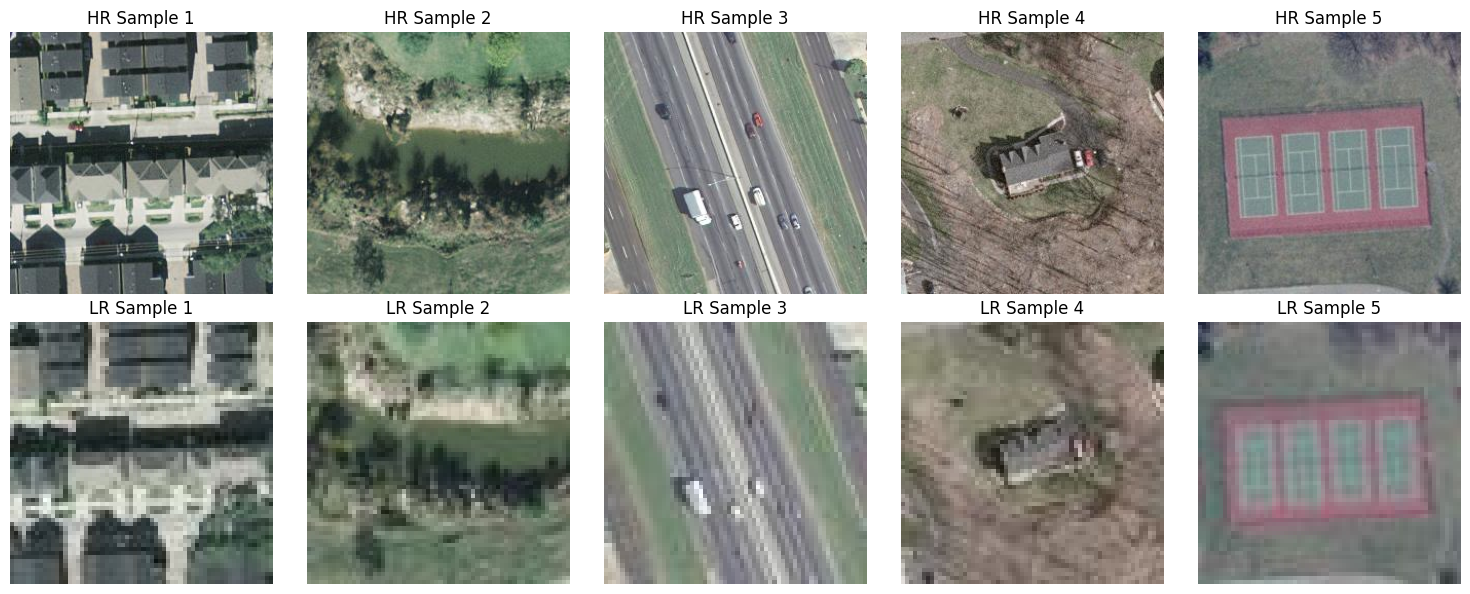

In [77]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import os

# Step 3: Visualize HR-LR Pairs
# Load the preprocessed HR and LR tensors
OUT_FOLDER = r"C:\SR_Project(2ndsem)\DataSet"
test_hr = torch.load(os.path.join(OUT_FOLDER, 'test_HR.pt'))
test_lr = torch.load(os.path.join(OUT_FOLDER, 'test_LR.pt'))

# Select 5 random samples
indices = np.random.choice(len(test_hr), 5, replace=False)
hr_samples = test_hr[indices].permute(0, 2, 3, 1).numpy()  # [N, C, H, W] -> [N, H, W, C]
lr_samples = test_lr[indices].permute(0, 2, 3, 1).numpy()

# Plot HR-LR pairs
plt.figure(figsize=(15, 6))
for i in range(5):
    # HR image
    plt.subplot(2, 5, i + 1)
    plt.imshow(hr_samples[i])
    plt.title(f'HR Sample {i+1}')
    plt.axis('off')
    # LR image
    plt.subplot(2, 5, i + 6)
    plt.imshow(lr_samples[i])
    plt.title(f'LR Sample {i+1}')
    plt.axis('off')
plt.tight_layout()
plt.show()

# Testing and Visualization Function (from training section)
def test_and_visualize(model, test_loader, device, save_dir="results"):
    os.makedirs(save_dir, exist_ok=True)
    model.eval()
    psnr_scores, ssim_scores = [], []
    
    with torch.no_grad():
        for i, (lr, hr) in enumerate(test_loader):
            lr, hr = lr.to(device), hr.to(device)
            sr = model(lr)
            
            # Convert tensors to numpy for visualization and metrics
            sr_np = sr.cpu().permute(0, 2, 3, 1).numpy()
            hr_np = hr.cpu().permute(0, 2, 3, 1).numpy()
            lr_np = lr.cpu().permute(0, 2, 3, 1).numpy()
            
            # Compute PSNR and SSIM for each image in the batch
            for j in range(sr_np.shape[0]):
                psnr = peak_signal_noise_ratio(hr_np[j], sr_np[j], data_range=1.0)
                ssim = structural_similarity(hr_np[j], sr_np[j], channel_axis=2, data_range=1.0)
                psnr_scores.append(psnr)
                ssim_scores.append(ssim)
                
                # Visualize the first 5 samples
                if i * test_loader.batch_size + j < 5:
                    plt.figure(figsize=(15, 5))
                    # LR
                    plt.subplot(1, 3, 1)
                    plt.imshow(lr_np[j])
                    plt.title('Low Resolution')
                    plt.axis('off')
                    # SR
                    plt.subplot(1, 3, 2)
                    plt.imshow(sr_np[j])
                    plt.title(f'Super-Resolved\nPSNR: {psnr:.2f}, SSIM: {ssim:.2f}')
                    plt.axis('off')
                    # HR
                    plt.subplot(1, 3, 3)
                    plt.imshow(hr_np[j])
                    plt.title('High Resolution')
                    plt.axis('off')
                    plt.tight_layout()
                    plt.savefig(os.path.join(save_dir, f'sample_{i * test_loader.batch_size + j + 1}.png'))
                    plt.show()
    
    avg_psnr = np.mean(psnr_scores)
    avg_ssim = np.mean(ssim_scores)
    print(f'Average PSNR: {avg_psnr:.2f}, Average SSIM: {avg_ssim:.2f}')

# Example usage of test_and_visualize (assuming model, test_loader, and device are defined)
# test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)
# test_and_visualize(model, test_loader, device, save_dir=r"C:\SR_Project(2ndsem)\DataSet\results")

Loaded checkpoint from C:\SR_Project(2ndsem)\DataSet\checkpoints\checkpoint_epoch_30.pth
Average PSNR: 21.65 dB
Average SSIM: 0.3493


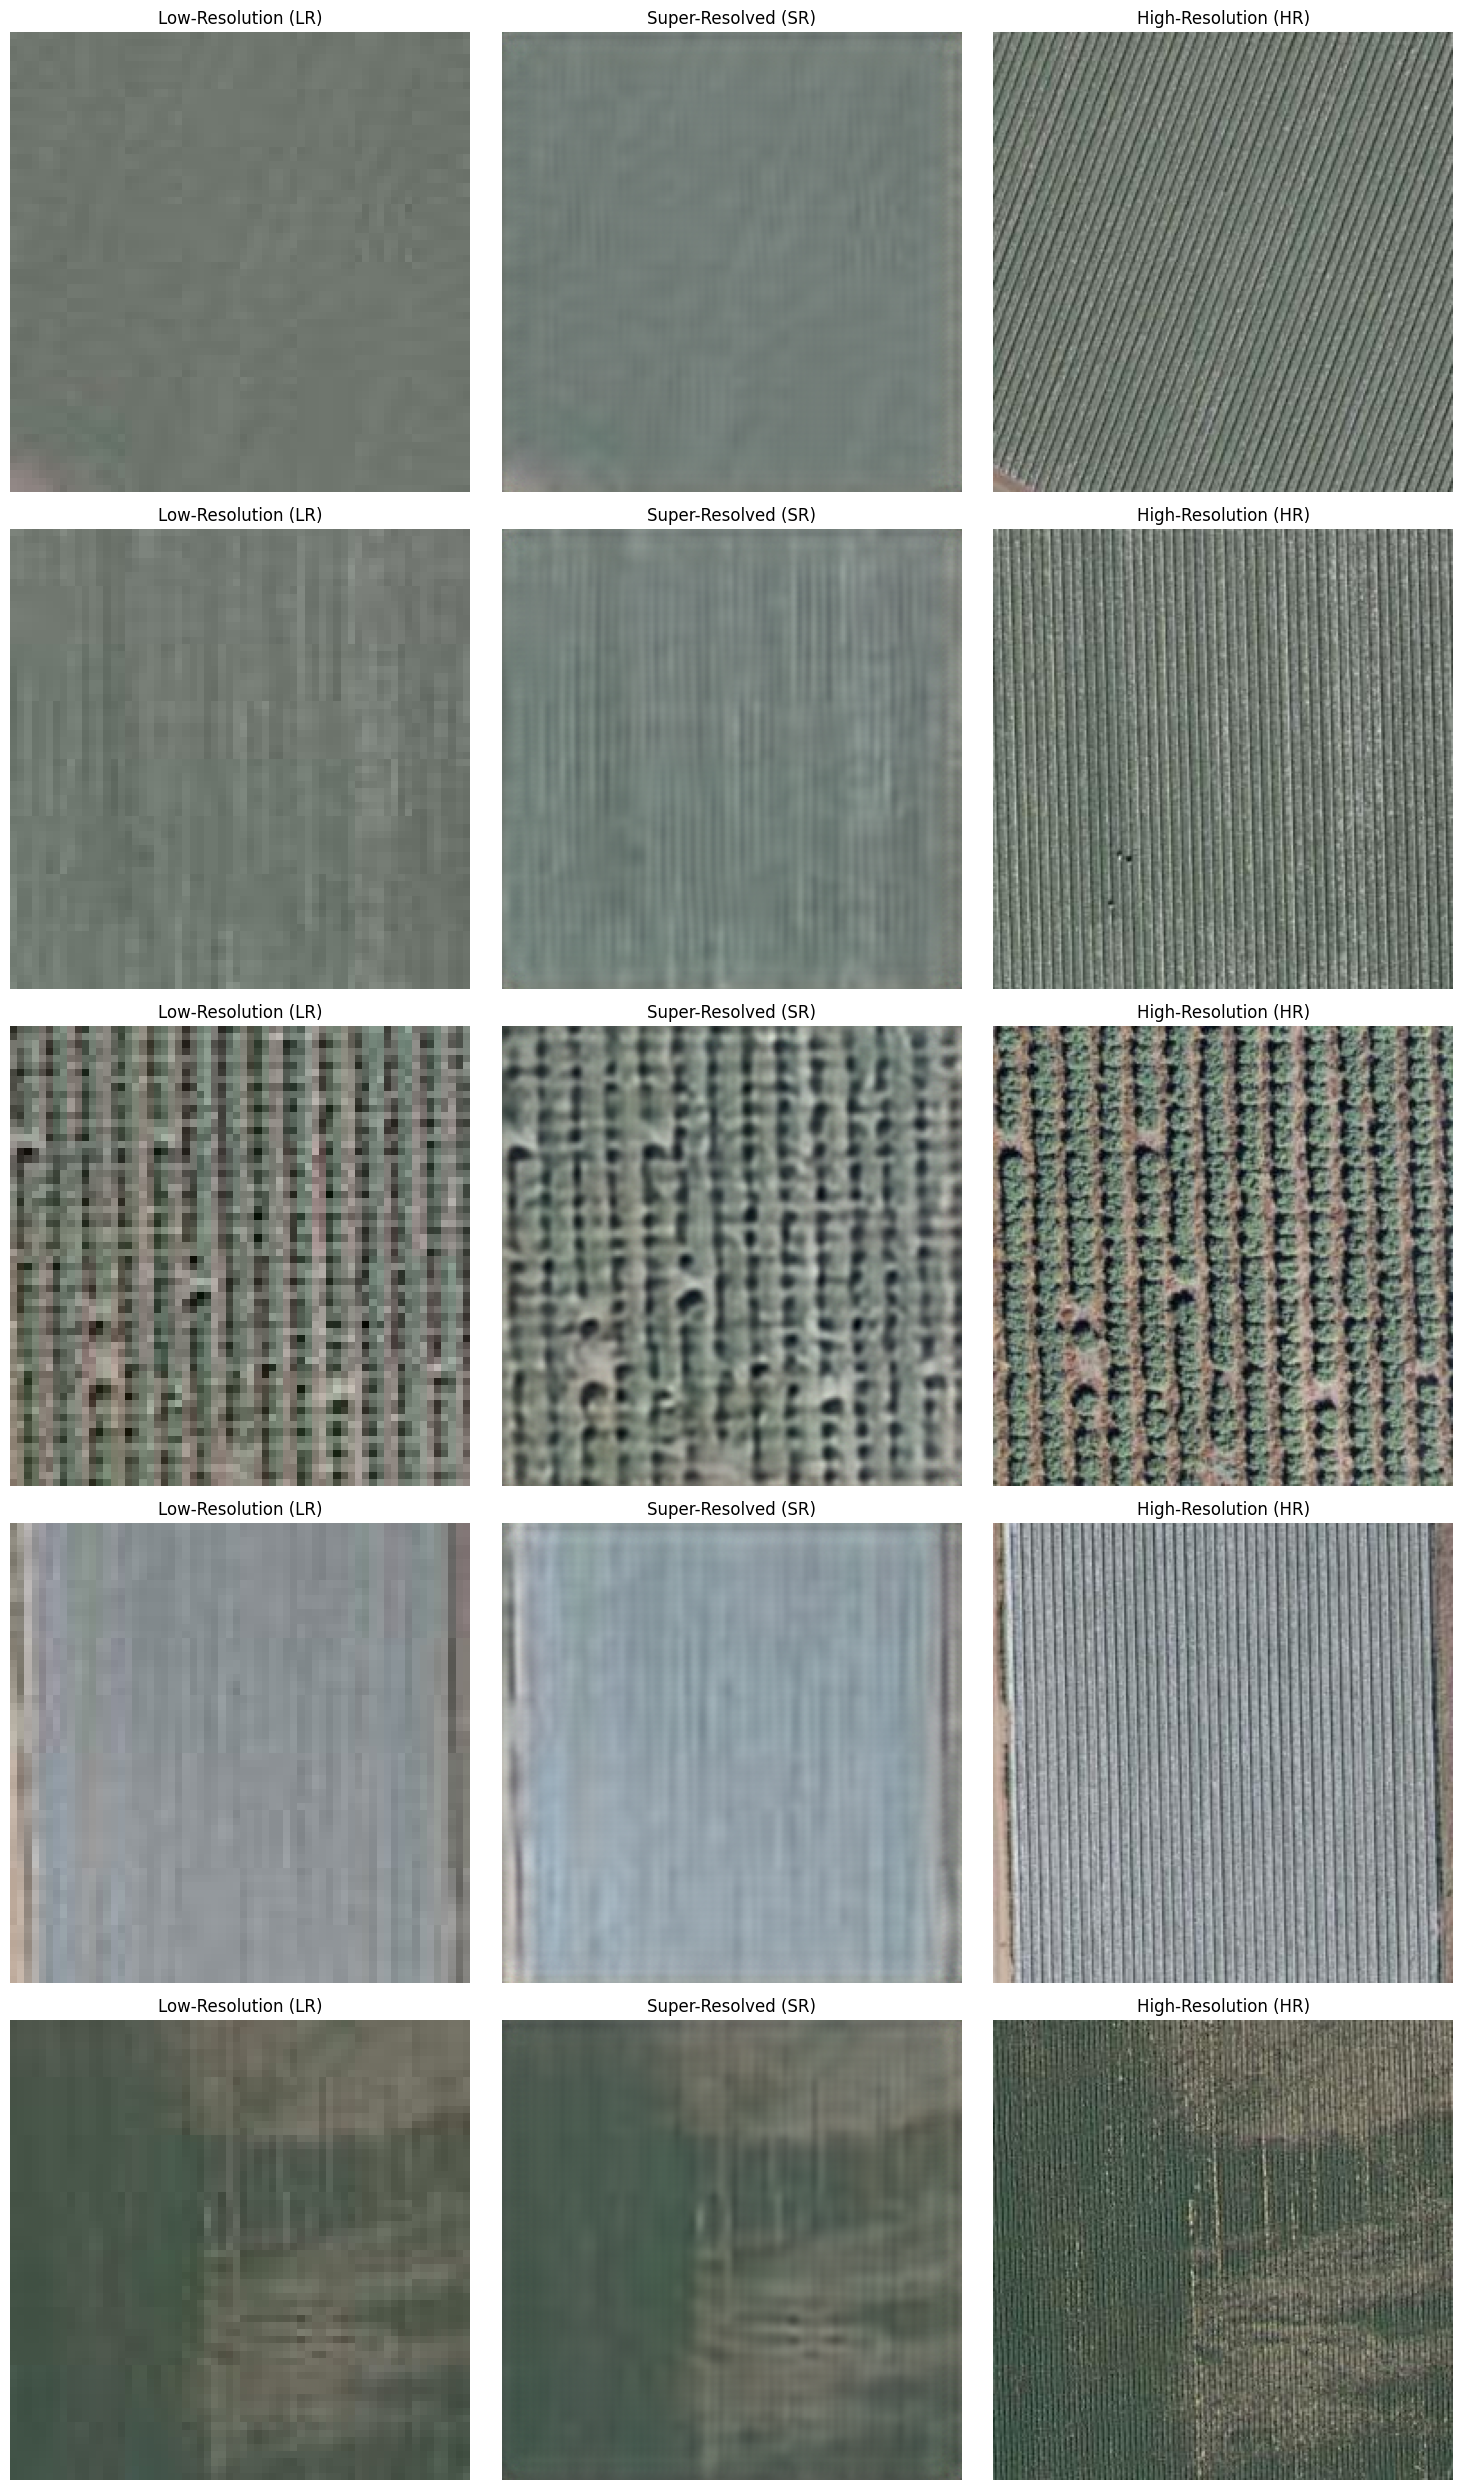

In [79]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import numpy as np
import os

# Define the testing function
def test_model(model, test_loader, device, num_samples=5):
    model.eval()
    psnr_values = []
    ssim_values = []
    sample_images = []

    with torch.no_grad():
        for i, (lr, hr) in enumerate(test_loader):
            lr, hr = lr.to(device), hr.to(device)
            sr = model(lr)
            
            # Convert tensors to numpy for metrics and visualization
            lr_np = lr.cpu().numpy().transpose(0, 2, 3, 1)  # [B, H, W, C]
            hr_np = hr.cpu().numpy().transpose(0, 2, 3, 1)
            sr_np = sr.cpu().numpy().transpose(0, 2, 3, 1)
            
            # Clip to [0, 1] for valid image range
            sr_np = np.clip(sr_np, 0, 1)
            hr_np = np.clip(hr_np, 0, 1)
            
            # Compute PSNR and SSIM for each image in the batch
            for j in range(lr.shape[0]):
                psnr = peak_signal_noise_ratio(hr_np[j], sr_np[j], data_range=1.0)
                ssim = structural_similarity(hr_np[j], sr_np[j], multichannel=True, data_range=1.0, channel_axis=2)
                psnr_values.append(psnr)
                ssim_values.append(ssim)
                
                # Store first few samples for visualization
                if len(sample_images) < num_samples:
                    sample_images.append((lr_np[j], sr_np[j], hr_np[j]))
            
            if len(sample_images) >= num_samples:
                break
    
    # Calculate average metrics
    avg_psnr = np.mean(psnr_values)
    avg_ssim = np.mean(ssim_values)
    print(f"Average PSNR: {avg_psnr:.2f} dB")
    print(f"Average SSIM: {avg_ssim:.4f}")
    
    # Visualize results
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, num_samples * 5))
    titles = ['Low-Resolution (LR)', 'Super-Resolved (SR)', 'High-Resolution (HR)']
    
    for i in range(num_samples):
        lr_img, sr_img, hr_img = sample_images[i]
        images = [lr_img, sr_img, hr_img]
        
        for j in range(3):
            ax = axes[i, j] if num_samples > 1 else axes[j]
            ax.imshow(images[j])
            ax.set_title(titles[j])
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    return avg_psnr, avg_ssim

# Main testing script
if __name__ == "__main__":
    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Define paths
    lr_path = r"C:\SR_Project(2ndsem)\DataSet\test_LR.pt"
    hr_path = r"C:\SR_Project(2ndsem)\DataSet\test_HR.pt"
    checkpoint_path = r"C:\SR_Project(2ndsem)\DataSet\checkpoints\checkpoint_epoch_30.pth"
    
    # Define transformations
    transform = transforms.Compose([
        transforms.Lambda(lambda x: x if x.dtype == torch.float32 else x.float() / 255.0)
    ])
    
    # Prepare test dataset and dataloader
    test_dataset = SRDataset(lr_path=lr_path, hr_path=hr_path, transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)
    
    # Initialize model
    model = ReFDN(in_channels=3, num_features=64, num_blocks=8, scale=4).to(device)
    
    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded checkpoint from {checkpoint_path}")
    
    # Test the model and visualize results
    avg_psnr, avg_ssim = test_model(model, test_loader, device, num_samples=5)

In [81]:
# Inspect test_LR.pt
lr_data = torch.load(r"C:\SR_Project(2ndsem)\DataSet\test_LR.pt")
print("LR Data Shape:", lr_data.shape)

LR Data Shape: torch.Size([420, 3, 64, 64])


In [82]:
transform = transforms.Compose([
    transforms.Lambda(lambda x: x if x.dtype == torch.float32 else x.float() / 255.0)
])

In [84]:
# Inside SRDataset.__getitem__
def __getitem__(self, idx):
    lr_image = self.lr_data[idx]
    hr_image = self.hr_data[idx]
    print("LR Image Shape:", lr_image.shape)  # Should be [3, 64, 64]
    if self.transform:
        lr_image = self.transform(lr_image)
        hr_image = self.transform(hr_image)
    return lr_image, hr_image

## Notes
- **Dataset**: UC Merced LandUse, preprocessed into HR (256x256) and LR (64x64) images for scale=4.
- **Model**: ReFDN with MultiConv for re-parameterization, 48 features, 8 ReFDB blocks.
- **Re-Parameterization**: MultiConv combines 1x1, 3x3, 5x5 convolutions during training, fused into a single 3x3 convolution for inference.
- **Training**: 30 epochs, L1 loss, Adam optimizer, MultiStepLR scheduler (halves LR at epochs 15, 25).
- **Evaluation**: PSNR and SSIM on test set, with visualization of LR, SR, SR (reparam), and HR images.
- **Environment**: Uses global Python 3.13.2 with `torch`, `torchvision`, `numpy`, `pillow`, `scikit-image`, `tqdm`, `matplotlib`, `jupyter`, `ipykernel`.
- **Hardware**: GPU recommended (CUDA 12.7). Set `num_workers=0` for Windows compatibility.
- **Performance**: Expect PSNR ~25-26, SSIM ~0.65-0.70 after 30 epochs.